<a href="https://colab.research.google.com/github/AyatM711/CodVeda-_Intership/blob/main/Level3_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Level 3 Tasks
Task 1: Predictive Modeling (Classification)

Goal: Build and evaluate classification models to predict customer churn.
## Used data set : Churn-bigml-80  dataset
1-load the data set and import the important libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style("whitegrid")
df = pd.read_csv("churn.csv")
print("Dataset shape:", df.shape)
print(df.head())
print("\nMissing values:\n", df.isnull().sum().sum(), "total")
print("\nChurn distribution:\n", df["Churn"].value_counts())
print(f"\nChurn rate: {df['Churn'].mean()*100:.1f}%")


Dataset shape: (2666, 20)
  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78

# 2. Preprocess the data

In [3]:


# 2a. Encode the target (True/False -> 1/0)
df["Churn"] = df["Churn"].astype(int)

# 2b. Encode binary categorical columns (Yes/No -> 1/0)
binary_cols = ["International plan", "Voice mail plan"]
for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

# 2c. Drop high-cardinality / low-signal identifier columns
#     'State' (51 unique values) and 'Area code' (only 3 values, not
#     meaningfully predictive) are dropped to keep the feature set clean.
df = df.drop(columns=["State", "Area code"])

print("\nColumns after preprocessing:")
print(df.columns.tolist())

# 2d. Split features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

# 2e. Train/test split (stratified, since churn is imbalanced ~14.5%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

# 2f. Feature scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Columns after preprocessing:
['Account length', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

Train size: 2132  |  Test size: 534


## 3. Train and test multiple classification models

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

results = []
trained_models = {}

for name, model in models.items():
    # Logistic Regression benefits from scaled features; tree-based
    # models are scale-invariant, so we use the unscaled versions for them.
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1-Score": f1
    })
    trained_models[name] = model

    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False)
print("\n=== Model Comparison (sorted by F1-Score) ===")
print(results_df.to_string(index=False))


--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.87      0.95      0.91       456
       Churn       0.41      0.19      0.26        78

    accuracy                           0.84       534
   macro avg       0.64      0.57      0.59       534
weighted avg       0.80      0.84      0.82       534


--- Decision Tree ---
              precision    recall  f1-score   support

    No Churn       0.94      0.95      0.94       456
       Churn       0.68      0.65      0.67        78

    accuracy                           0.90       534
   macro avg       0.81      0.80      0.81       534
weighted avg       0.90      0.90      0.90       534


--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.96      1.00      0.98       456
       Churn       0.98      0.73      0.84        78

    accuracy                           0.96       534
   macro avg       0.97      0.86      0.91       534

# 4. Hyperparameter tuning with GridSearchCV (Random Forest)

In [5]:
print("\nRunning GridSearchCV on Random Forest...")

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1-score: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_prec = precision_score(y_test, y_pred_tuned)
tuned_rec = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("\n--- Tuned Random Forest (Test Set) ---")
print(classification_report(y_test, y_pred_tuned, target_names=["No Churn", "Churn"]))


Running GridSearchCV on Random Forest...
Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1-score: 0.8243

--- Tuned Random Forest (Test Set) ---
              precision    recall  f1-score   support

    No Churn       0.95      0.99      0.97       456
       Churn       0.93      0.72      0.81        78

    accuracy                           0.95       534
   macro avg       0.94      0.85      0.89       534
weighted avg       0.95      0.95      0.95       534



# 5. Visualize: Model comparison , confusion matrix and feature importance


Saved plot: task1_classification_results.png


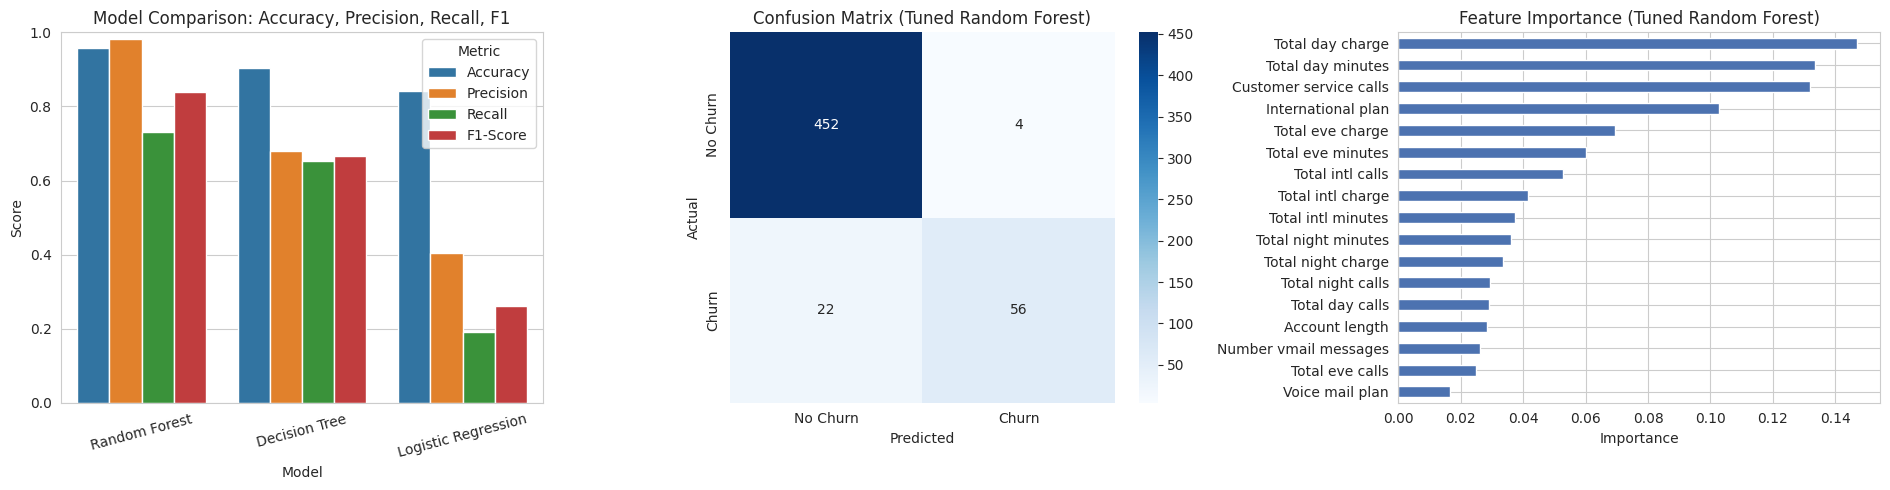

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Model comparison bar chart
results_melt = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=results_melt, x="Model", y="Score", hue="Metric", ax=axes[0])
axes[0].set_title("Model Comparison: Accuracy, Precision, Recall, F1")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)

# Confusion matrix for the tuned Random Forest
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"], ax=axes[1])
axes[1].set_title("Confusion Matrix (Tuned Random Forest)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Feature importance from the tuned Random Forest
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)
importances.plot(kind="barh", ax=axes[2], color="#4C72B0")
axes[2].set_title("Feature Importance (Tuned Random Forest)")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("task1_classification_results.png", dpi=150)
print("\nSaved plot: task1_classification_results.png")
